Dado que el entrenamiento de redes neuronales es una tarea  muy costosa, **se recomienda ejecutar el notebooks en [Google Colab](https://colab.research.google.com)**, por supuesto también se puede ejecutar en local.

Al entrar en [Google Colab](https://colab.research.google.com) bastará con hacer click en `upload` y subir este notebook. No olvide luego descargarlo en `File->Download .ipynb`

**El examen deberá ser entregado con las celdas ejecutadas, si alguna celda no está ejecutadas no se contará.**

El examen se divide en tres partes, con la puntuación que se indica a continuación. La puntuación máxima será 10.

    
- [Actividad 1: Redes Recurrentes](#actividad_1): 10 pts
    - [Cuestión 1](#3.1): 2.5 pt
    - [Cuestión 2](#3.2): 2.5 pt
    - [Cuestión 3](#3.3): 2.5 pts
    - [Cuestión 4](#3.4): 1.25 pts
    - [Cuestión 5](#3.5): 1.25 pts



In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

<a name='actividad_1'></a>
# Actividad 1: Redes Recurrentes


- [Cuestión 1](#3.1): 2.5 pt
- [Cuestión 2](#3.2): 2.5 pt
- [Cuestión 3](#3.3): 2.5 pts
- [Cuestión 4](#3.4): 1.25 pts
- [Cuestión 5](#3.5): 1.25 pts

Vamos a usar un dataset de las temperaturas mínimas diarias en Melbourne. La tarea será la de predecir la temperatura mínima en dos días. Puedes usar técnicas de series temporales vistas en otras asignaturas, pero no es necesario.


In [2]:
dataset_url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/daily-min-temperatures.csv'
data_dir = tf.keras.utils.get_file('daily-min-temperatures.csv', origin=dataset_url)

67921/67921 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [3]:
df = pd.read_csv(data_dir, parse_dates=['Date'])
df.head()

,Date,Temp
0,1981-01-01,20.7
1,1981-01-02,17.9
2,1981-01-03,18.8
3,1981-01-04,14.6
4,1981-01-05,15.8


In [4]:
temperatures = df['Temp'].values
print('number of samples:', len(temperatures))
train_data = temperatures[:3000]
test_data = temperatures[3000:]
print('number of train samples:', len(train_data))
print('number of test samples:', len(test_data))
print('firsts trainn samples:', train_data[:10])

number of samples: 3650
number of train samples: 3000
number of test samples: 650
firsts trainn samples: [20.7 17.9 18.8 14.6 15.8 15.8 15.8 17.4 21.8 20. ]


<a name='3.1'></a>
## Cuestión 1: Convierta `train_data` y `test_data`  en ventanas de tamaño 5, para predecir el valor en 2 días

En la nomenclatura de [Introduction_to_RNN_Time_Series.ipynb](https://github.com/ezponda/intro_deep_learning/blob/main/class/RNN/Introduction_to_RNN_Time_Series.ipynb)
```python
past, future = (5, 2)
```

Para las primeras 10 muestras de train_data `[20.7, 17.9, 18.8, 14.6, 15.8, 15.8, 15.8, 17.4, 21.8, 20. ]` el resultado debería ser:

```python
x[0] : [20.7, 17.9, 18.8, 14.6, 15.8] , y[0]: 15.8
x[1] : [17.9, 18.8, 14.6, 15.8, 15.8] , y[1]: 17.4
x[2] : [18.8, 14.6, 15.8, 15.8, 15.8] , y[2]: 21.8
x[3] : [14.6, 15.8, 15.8, 15.8, 17.4] , y[3]: 20.             
```

In [5]:
# Ventanado deslizante: past = window size, future = horizon de predicción
def windowing(data, past, future):
    X, y = [], []
    for i in range(len(data) - past - future + 1):
        X.append(data[i:i + past])
        y.append(data[i + past + future - 1])
    return np.array(X), np.array(y)


In [6]:
past, future = (5, 2)
X_train, y_train = windowing(train_data, past, future)
X_test,  y_test  = windowing(test_data,  past, future)

# Las RNN esperan entrada 3D (muestras, timesteps, features), no 2D como en tabulares
X_train = X_train[..., np.newaxis]
X_test  = X_test[...,  np.newaxis]

print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_test  shape:', X_test.shape)
print('y_test  shape:', y_test.shape)
print()
for i in range(4):
    print(f'x[{i}] : {X_train[i].flatten().tolist()} , y[{i}]: {y_train[i]}')


X_train shape: (2994, 5, 1)
y_train shape: (2994,)
X_test  shape: (644, 5, 1)
y_test  shape: (644,)

x[0] : [20.7, 17.9, 18.8, 14.6, 15.8] , y[0]: 15.8
x[1] : [17.9, 18.8, 14.6, 15.8, 15.8] , y[1]: 17.4
x[2] : [18.8, 14.6, 15.8, 15.8, 15.8] , y[2]: 21.8
x[3] : [14.6, 15.8, 15.8, 15.8, 17.4] , y[3]: 20.0


<a name='3.2'></a>
## Cuestión 2: Cree un modelo recurrente de dos capas GRU para predecir con las ventanas de la cuestión anterior.


In [7]:
# Deep RNN: apilamos dos GRU para aprender representaciones más complejas.
# GRU sobre SimpleRNN porque sus gates evitan el vanishing gradient.
# return_sequences=True en la primera para que la segunda capa reciba toda la sequence.
# La segunda GRU devuelve solo el último state: arquitectura many-to-one.
inputs  = keras.layers.Input(shape=(past, 1))
x       = keras.layers.GRU(32, return_sequences=True)(inputs)
x       = keras.layers.GRU(32)(x)
outputs = keras.layers.Dense(1)(x)

model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 5, 1)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ (None, 5, 32)          │         3,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         6,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,729 (38.00 KB)

 Trainable params: 9,729 (38.00 KB)

 Non-trainable params: 0 (0.00 B)

In [8]:
es_callback = keras.callbacks.EarlyStopping(
    monitor="val_loss", min_delta=0, patience=10)

history = model.fit(
    X_train, y_train,
    epochs=200,
    validation_split=0.2, shuffle=True, batch_size = 64, callbacks=[es_callback]
)

Epoch 1/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - loss: 83.3669 - mae: 8.0145 - val_loss: 50.4670 - val_mae: 6.0827
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 28.6095 - mae: 4.2827 - val_loss: 28.3319 - val_mae: 4.2908
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 20.2086 - mae: 3.5683 - val_loss: 22.1544 - val_mae: 3.7606
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 17.8377 - mae: 3.3524 - val_loss: 19.3734 - val_mae: 3.5250
Epoch 5/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 16.6099 - mae: 3.2333 - val_loss: 17.7402 - val_mae: 3.3641
Epoch 6/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 14.7900 - mae: 3.0164 - val_loss: 15.6847 - val_mae: 3.1139
Epoch 7/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 13.0803 - mae: 2.8104 - val_loss: 13.8934 - val_mae: 2.9114
Epoch 8/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 11.8767 - mae: 2.6701 - val_loss: 12.2303 - val_mae: 2.7136
Epoch 9/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9540 - mae: 2.0677 
Test Loss (MSE): 6.9540
Test MAE: 2.0677


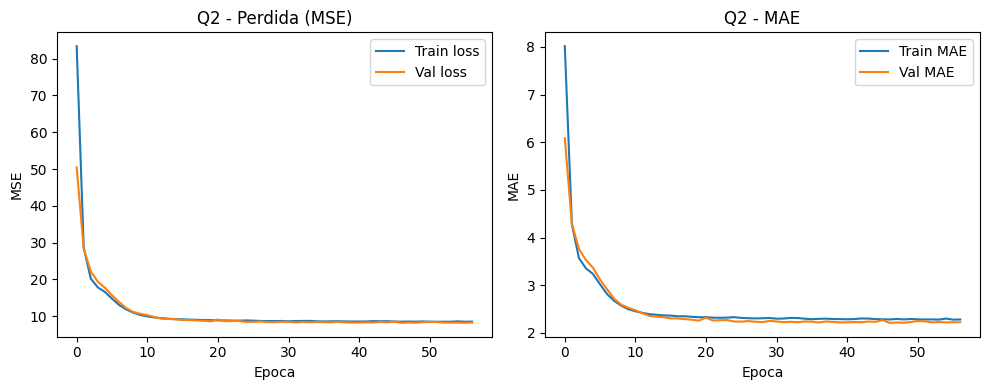

In [9]:
results = model.evaluate(X_test, y_test, verbose=1)
# Q2 esta en grados (sin normalizar): guardo sus metricas para comparar con Q3
mse_q2_real, mae_q2_real = results[0], results[1]
print('Test Loss (MSE): {:.4f}'.format(results[0]))
print('Test MAE: {:.4f}'.format(results[1]))

# Curvas de entrenamiento
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('Q2 - Perdida (MSE)')
plt.xlabel('Epoca'); plt.ylabel('MSE'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Q2 - MAE')
plt.xlabel('Epoca'); plt.ylabel('MAE'); plt.legend()
plt.tight_layout()
plt.show()


<a name='3.3'></a>
## Cuestión 3: Añada más features a la series temporal, por ejemplo `portion_year`. Cree un modelo que mejore al anterior.


In [10]:
df['portion_year'] = df['Date'].dt.dayofyear / 365.0

# Codificacion ciclica del dia del anio: evita el salto 1.0 -> 0.0 entre anios
day = df['Date'].dt.dayofyear
df['sin_year'] = np.sin(2 * np.pi * day / 365.0)
df['cos_year'] = np.cos(2 * np.pi * day / 365.0)

df_multi = df[['Temp', 'portion_year', 'sin_year', 'cos_year']].copy()

train_data = df_multi.iloc[:3000].copy()
test_data  = df_multi.iloc[3000:].copy()

# fit solo en train para no filtrar info del test (data leakage)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data)
test_scaled  = scaler.transform(test_data)

print('Features:', df_multi.columns.tolist())
print('Train shape:', train_data.shape)
print('Test shape :', test_data.shape)
print('Media train (Temp):', scaler.mean_[0].round(3), '| Std train (Temp):', scaler.scale_[0].round(3))
df_multi.head()


Features: ['Temp', 'portion_year', 'sin_year', 'cos_year']
Train shape: (3000, 4)
Test shape : (650, 4)
Media train (Temp): 11.241 | Std train (Temp): 4.111


,Temp,portion_year,sin_year,cos_year
0,20.7,0.002740,0.017213,0.999852
1,17.9,0.005479,0.034422,0.999407
2,18.8,0.008219,0.051620,0.998667
3,14.6,0.010959,0.068802,0.997630
4,15.8,0.013699,0.085965,0.996298


In [11]:
# Ventanado con varias features: cada paso es un vector de n_features
def windowing_multi(data, past, future, target_col=0):
    values = data if isinstance(data, np.ndarray) else data.values
    X, y = [], []
    for i in range(len(values) - past - future + 1):
        X.append(values[i:i + past, :])
        y.append(values[i + past + future - 1, target_col])
    return np.array(X), np.array(y)

past, future = (5, 2)
X_train, y_train = windowing_multi(train_scaled, past, future, target_col=0)
X_test,  y_test  = windowing_multi(test_scaled,  past, future, target_col=0)

n_features = X_train.shape[2]
print('X_train shape:', X_train.shape)
print('y_train shape:', y_train.shape)
print('X_test  shape:', X_test.shape)
print('y_test  shape:', y_test.shape)
print('n_features  :', n_features)


X_train shape: (2994, 5, 4)
y_train shape: (2994,)
X_test  shape: (644, 5, 4)
y_test  shape: (644,)
n_features  : 4


In [12]:
# GRU apiladas (deep RNN) + dropout para regularizar y H mayor que en Q2.
# GRU sobre SimpleRNN: los gates controlan el flujo y mitigan el vanishing gradient.
# return_sequences=True salvo en la ultima -> many-to-one (un solo valor de salida).
inputs  = keras.layers.Input(shape=(past, n_features))
x       = keras.layers.GRU(48, return_sequences=True)(inputs)
x       = keras.layers.Dropout(0.2)(x)
x       = keras.layers.GRU(48)(x)
x       = keras.layers.Dropout(0.2)(x)
outputs = keras.layers.Dense(1)(x)

model = keras.Model(inputs=inputs, outputs=outputs)
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 5, 4)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 5, 48)          │         7,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 48)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_3 (GRU)                     │ (None, 48)             │        14,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            49 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,937 (85.69 KB)

 Trainable params: 21,937 (85.69 KB)

 Non-trainable params: 0 (0.00 B)

**Mejoras sobre el modelo base de Q2.**

Mejoro por dos vias:

1. **Datos**: ademas de `portion_year`, anado la codificacion ciclica seno/coseno del dia del anio para representar la estacionalidad sin el salto artificial de fin de anio, y estandarizo (fit solo en train).
2. **Modelo**: apilo capas GRU (deep RNN), aumento el tamano del estado oculto y aniado Dropout como regularizacion.

Mantengo GRU por sus puertas (mitigan el vanishing gradient) y la arquitectura many-to-one porque la salida es un unico valor. Comparo Q2 y Q3 en la misma escala (grados) desnormalizando las metricas.


In [13]:
es_callback = keras.callbacks.EarlyStopping(
    monitor="val_loss", min_delta=0, patience=10)

history = model.fit(
    X_train, y_train,
    epochs=200,
    validation_split=0.2, shuffle=True, batch_size = 64, callbacks=[es_callback]
)

Epoch 1/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 0.6061 - mae: 0.6128 - val_loss: 0.4652 - val_mae: 0.5352
Epoch 2/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4734 - mae: 0.5450 - val_loss: 0.4573 - val_mae: 0.5264
Epoch 3/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.4664 - mae: 0.5447 - val_loss: 0.4642 - val_mae: 0.5281
Epoch 4/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4616 - mae: 0.5398 - val_loss: 0.4533 - val_mae: 0.5246
Epoch 5/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4605 - mae: 0.5426 - val_loss: 0.4615 - val_mae: 0.5280
Epoch 6/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4582 - mae: 0.5404 - val_loss: 0.4510 - val_mae: 0.5164
Epoch 7/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4507 - mae: 0.5351 - val_loss: 0.4336 - val_mae: 0.5125
Epoch 8/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.4590 - mae: 0.5394 - val_loss: 0.4335 - val_mae: 0.5117
Epoch 9/200
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.

21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.3603 - mae: 0.4654 
Q3 - Test Loss (MSE, espacio normalizado): 0.3603
Q3 - Test MAE  (espacio normalizado):       0.4654

Q3 - Test MSE en escala original (oC^2): 6.0893
Q3 - Test MAE en escala original (oC):   1.9133

--- Comparativa Q2 vs Q3 (misma escala, oC) ---
                     Q2          Q3
MSE (oC^2)       6.9540      6.0893
MAE (oC)         2.0677      1.9133
Mejora MAE:  0.154 oC (7.5%)


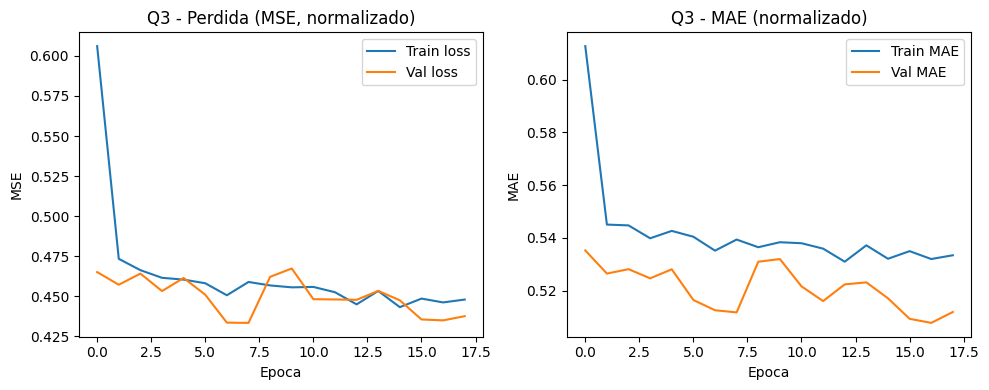

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step

MAE en escala original (oC): 1.913


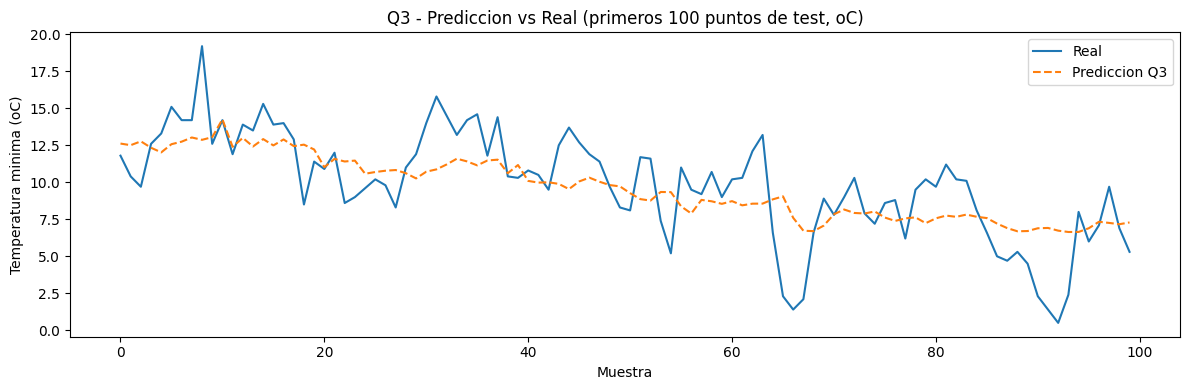

In [14]:
results_q3 = model.evaluate(X_test, y_test, verbose=1)

# Metricas en espacio normalizado: no comparables directamente con Q2 (que esta en oC)
print('Q3 - Test Loss (MSE, espacio normalizado): {:.4f}'.format(results_q3[0]))
print('Q3 - Test MAE  (espacio normalizado):       {:.4f}'.format(results_q3[1]))

# Vuelvo a la escala original: MSE_real = MSE_norm * std**2 , MAE_real = MAE_norm * std
temp_mean, temp_std = scaler.mean_[0], scaler.scale_[0]
mse_q3_real = results_q3[0] * (temp_std ** 2)
mae_q3_real = results_q3[1] * temp_std

print()
print('Q3 - Test MSE en escala original (oC^2): {:.4f}'.format(mse_q3_real))
print('Q3 - Test MAE en escala original (oC):   {:.4f}'.format(mae_q3_real))

# Comparativa en las mismas unidades (oC)
print()
print('--- Comparativa Q2 vs Q3 (misma escala, oC) ---')
print('             {:>10}  {:>10}'.format('Q2', 'Q3'))
print('MSE (oC^2)   {:>10.4f}  {:>10.4f}'.format(mse_q2_real, mse_q3_real))
print('MAE (oC)     {:>10.4f}  {:>10.4f}'.format(mae_q2_real, mae_q3_real))
print('Mejora MAE:  {:.3f} oC ({:.1f}%)'.format(
    mae_q2_real - mae_q3_real, 100 * (mae_q2_real - mae_q3_real) / mae_q2_real))

# Curvas de entrenamiento Q3
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train loss')
plt.plot(history.history['val_loss'], label='Val loss')
plt.title('Q3 - Perdida (MSE, normalizado)')
plt.xlabel('Epoca'); plt.ylabel('MSE'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Q3 - MAE (normalizado)')
plt.xlabel('Epoca'); plt.ylabel('MAE'); plt.legend()
plt.tight_layout()
plt.show()

# Predicciones de test desnormalizadas para comparar en grados
y_pred_q3 = model.predict(X_test).flatten()
y_test_real = y_test * temp_std + temp_mean
y_pred_real = y_pred_q3 * temp_std + temp_mean

mae_real = np.mean(np.abs(y_test_real - y_pred_real))
print(f'\nMAE en escala original (oC): {mae_real:.3f}')

plt.figure(figsize=(12, 4))
plt.plot(y_test_real[:100], label='Real', linewidth=1.5)
plt.plot(y_pred_real[:100], label='Prediccion Q3', linestyle='--')
plt.title('Q3 - Prediccion vs Real (primeros 100 puntos de test, oC)')
plt.xlabel('Muestra'); plt.ylabel('Temperatura minima (oC)'); plt.legend()
plt.tight_layout()
plt.show()


<a name='3.4'></a>
## Cuestión 4: ¿En cuáles de estas aplicaciones se usaría un arquitectura 'many-to-one'?

**a)** Clasificación de sentimiento en textos

**b)** Verificación de voz para iniciar el ordenador.

**c)** Generación de música.

**d)** Un clasificador que clasifique piezas de música según su autor.


**Respuesta: a, b y d.**

La arquitectura *many-to-one* recibe una secuencia y produce una unica salida. Aplicando ese criterio:

- **a)** Clasificacion de sentimiento: entrada = secuencia de palabras, salida = una etiqueta. Es *many-to-one*. **Se usaria**
- **b)** Verificacion de voz: entrada = secuencia temporal de audio, salida = decision binaria (verificado / no). Es *many-to-one*. **Se usaria**
- **c)** Generacion de musica: a partir de una entrada se genera una secuencia, es *one-to-many*. **NO se usaria**
- **d)** Clasificar piezas por autor: entrada = secuencia (audio o partitura), salida = una etiqueta de clase. Es *many-to-one*. **Se usaria**


<a name='3.5'></a>
## Cuestión 5: ¿Qué ventajas aporta el uso de word embeddings?

**a)** Permiten reducir la dimensión de entrada respecto al one-hot encoding.

**b)** Permiten descubrir la similaridad entre palabras de manera más intuitiva que con one-hot encoding.

**c)** Son una manera de realizar transfer learning en nlp.

**d)** Permiten visualizar las relaciones entre palabras con métodos de reducción de dimensioones como el PCA.


**Respuesta: las cuatro son correctas (a, b, c y d).**

- **a) Verdadero**. Con one-hot, cada palabra se representa con un vector de longitud igual al tamano del vocabulario (puede ser enorme), con un unico 1 y el resto ceros. Un embedding la representa con un vector denso de dimension mucho menor, reduciendo asi la dimensionalidad de la entrada a la red.

- **b) Verdadero**. Con one-hot, dos palabras cualesquiera son ortogonales y su distancia es siempre la misma, por lo que la representacion no informa de ninguna similitud. Con embeddings, palabras de significado parecido ocupan posiciones cercanas en el espacio vectorial, lo que si permite medir similitud.

- **c) Verdadero**. Una vez aprendido un embedding sobre un corpus grande, esos vectores pueden reutilizarse como capa de entrada de otro modelo y otra tarea de NLP: esa reutilizacion es precisamente la idea de *transfer learning*.

- **d) Verdadero**. Como los embeddings son vectores en un espacio continuo, se les pueden aplicar tecnicas de reduccion de dimension como PCA para proyectarlos a 2D o 3D y observar visualmente las relaciones entre palabras.
